In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib

X_test = np.load('../data/processed/X_test_processed.npy')
y_test = np.load('../data/processed/y_test.npy')

model = joblib.load('../models/xgb_model.pkl')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_month']

cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

preprocessor = joblib.load('../models/preprocessor.pkl')
cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

X_test_df = pd.DataFrame(X_test, columns=all_feature_names)

print(f"test samples: {X_test_df.shape[0]}")
print(f"features: {X_test_df.shape[1]}")
print(f"feature names sample: {all_feature_names[:6]}")

test samples: 1407
features: 35
feature names sample: ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_month', 'MultipleLines_No', 'MultipleLines_No phone service']


/Users/joyix/Coding/sideprojects/customer-churn-prediction/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## SHAP explainer and global summary plot

- `TreeExplainer` optimised for tree based models like xgboost
- computes SHAP value for every feature + prediction in test set
- each value shows how much a feature pushed a prediction up or down from the baseline
- red dots = high feature value pushed toward churn, blue = pushed away from churn

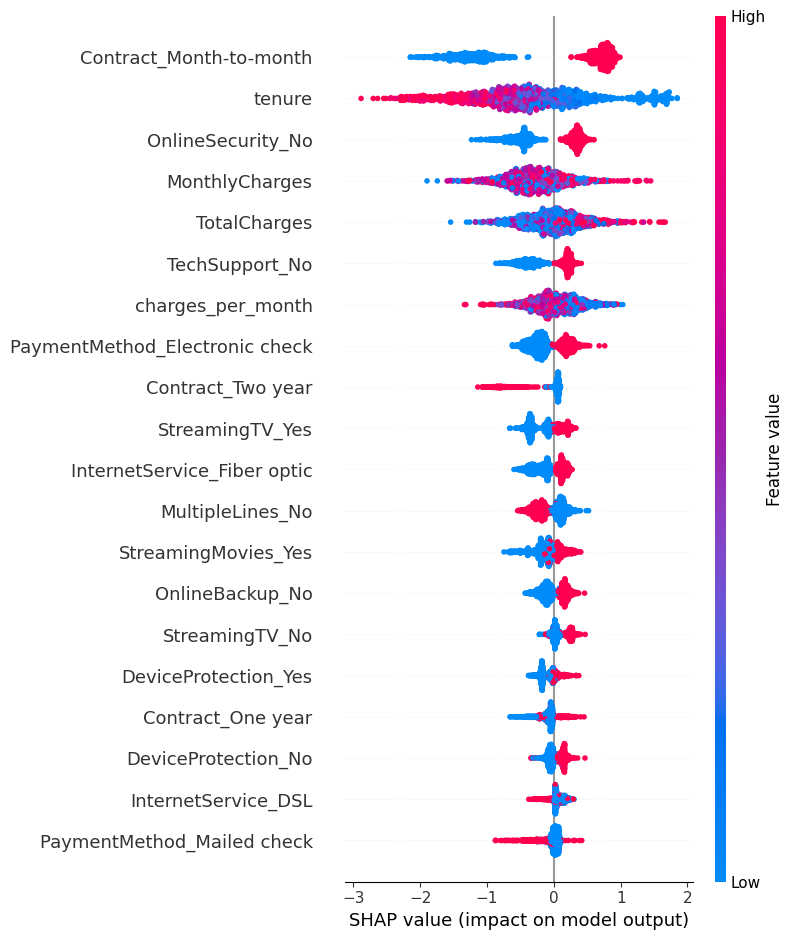

In [2]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test_df)

## mean absolute SHAP values

- cleaner version of summary plot above
- shows avg impact of each feature across all pred
- useful for communicating feature importance to a nontechnical person

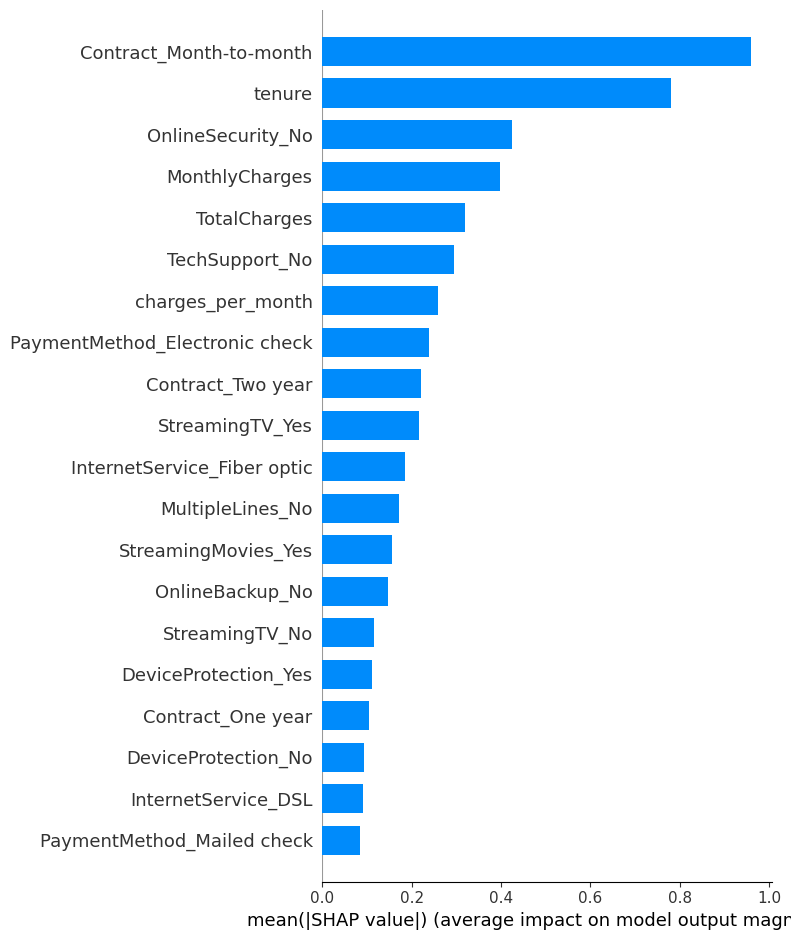

In [3]:
shap.summary_plot(plot_type="bar", shap_values=shap_values, features=X_test_df, feature_names=all_feature_names)

## waterfall plot for single high risk customer

- picks customer model is most confident will churn
- each bar shows how much one feature pushed the prediction up or down from the baseline

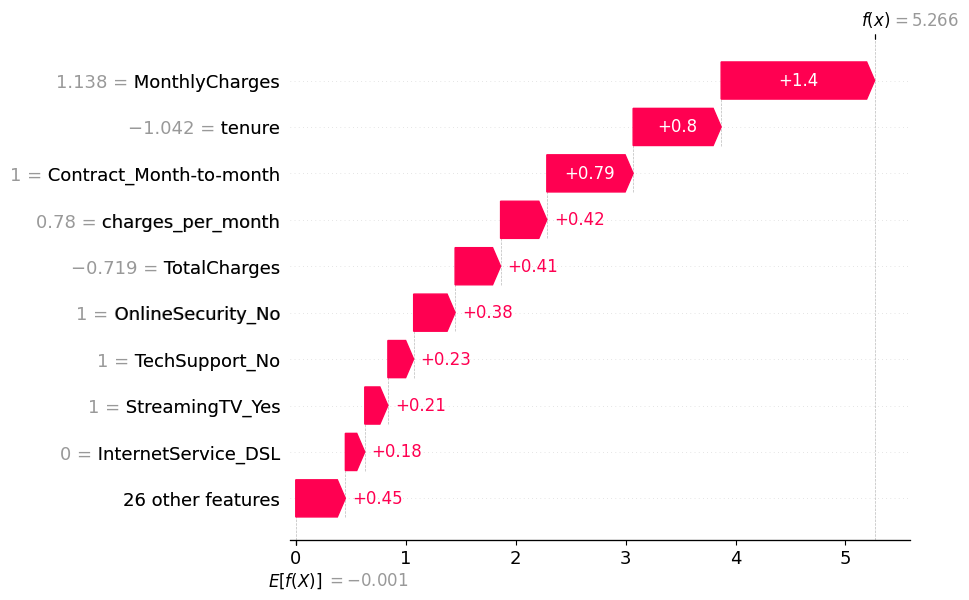

In [4]:
high_risk_idx = np.argmax(model.predict_proba(X_test)[:, 1])

explanation = shap.Explanation(
    values    = shap_values[high_risk_idx],
    base_values = explainer.expected_value,
    data      = X_test_df.iloc[high_risk_idx],
    feature_names = all_feature_names
)
shap.plots.waterfall(explanation)

## dependence plot for tenure

- shows how tenure relates to its SHAP impact across all test customers
- reveals threshold where long tenure stops being a churn risk factor

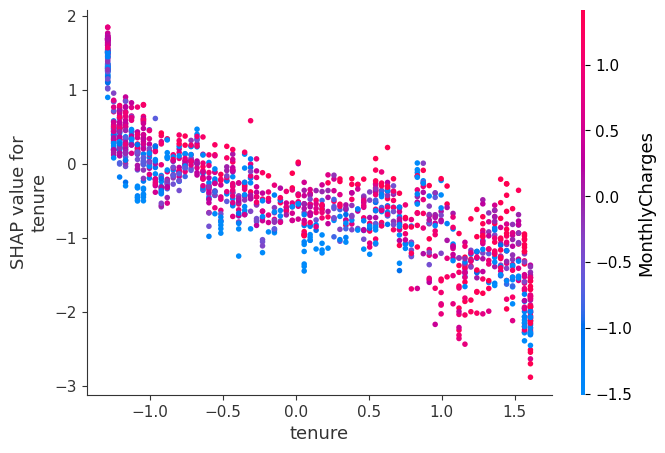

In [5]:
shap.dependence_plot('tenure', shap_values, X_test_df)

## dependence plot for tenure

- x axis is tenure (scaled), y axis is its shap impact on churn probability
- short tenure (left) pushes pred toward churn, long tenure (right) pushes away
- crossover from pos to neg SHAP values sits around mean tenure mark
- colour shows MonthlyCharges, pink = high bills, blue = low bills